In [1]:
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '2,3'
# os.chdir("hmr4d/")
from pathlib import Path
import pickle as pkl
import json
from collections import defaultdict
from tqdm import tqdm
import zipfile
import shutil

import numpy as np
np.set_printoptions(suppress=True, precision=6)
import matplotlib.pyplot as plt
from einops import einsum
from PIL import Image
import lovely_tensors as lt
lt.monkey_patch()
import imageio.v3 as iio
from smplx.joint_names import SMPLH_JOINT_NAMES
SMPLH_JOINT_NAMES = np.array(SMPLH_JOINT_NAMES[:22] + ['left_hand', 'right_hand'])
import torch

import hydra
from hydra import compose, initialize_config_module
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from hmr4d.configs import store_gvhmr  # noqa: F401

import hmr4d.model.gvhmr.gvhmr_pl_demo  # noqa: F401
from hmr4d.dataset.emdb.emdb_motion_test import EmdbSmplFullSeqDataset
from hmr4d.dataset.threedpw.threedpw_motion_test import ThreedpwSmplFullSeqDataset
from hmr4d.dataset.rich.rich_motion_test import RichSmplFullSeqDataset
from hmr4d.utils.body_model import BodyModelSMPLH, BodyModelSMPLX
from hmr4d.utils.eval.eval_utils import compute_global_metrics, compute_camcoord_metrics, topk_outlier_frames
from hmr4d.utils.geo.hmr_cam import estimate_K, normalize_kp2d, create_camera_sensor
from hmr4d.utils.geo_transform import compute_cam_angvel, apply_T_on_points, move_to_start_point_face_z
from hmr4d.utils.vis.renderer import Renderer, get_global_cameras_static, get_ground_params_from_points
from hmr4d.utils.video_io_utils import get_writer

device = 'cuda'

/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/utils/postprocess.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/home/guangyu/patrick/GVHMR/hmr4d/network/base_arch/embeddings/rotary_embedding.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


In [2]:
GlobalHydra.instance().clear()
with initialize_config_module(version_base="1.3", config_module="hmr4d.configs"):
    cfg = compose(config_name="demo")
    
pipeline = instantiate(cfg.pipeline, _recursive_=False).eval().to(device)
ckpt = {k.replace("pipeline.", ""):v for k,v in torch.load(cfg.ckpt_path, "cpu")['state_dict'].items()}
pipeline.load_state_dict(ckpt, strict=True)

/home/guangyu/patrick/GVHMR/hmr4d/model/gvhmr/pipeline/gvhmr_pipeline.py:321: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
[02/02 09:59:41][INFO] [EnDecoder] Use MM_V1_AMASS_LOCAL_BEDLAM_CAM for statistics!
/tmp/ipykernel_1111469/3117027921.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.ad

<All keys matched successfully>

In [2]:
smpl = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="neutral", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)
smpl_male = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="male", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)
smpl_female = BodyModelSMPLH(
    model_path="inputs/checkpoints/body_models", model_type="smpl",
    gender="female", num_betas=10, create_body_pose=False, 
    create_betas=False, create_global_orient=False, create_transl=False,
).to(device)

smplx = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="neutral", num_pca_comps=12, flat_hand_mean=False,
).to(device)
smplx_male = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="male", num_pca_comps=12, flat_hand_mean=False,
).to(device)
smplx_female = BodyModelSMPLX(
    model_path="inputs/checkpoints/body_models", model_type="smplx",
    gender="female", num_pca_comps=12, flat_hand_mean=False,
).to(device)

smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
faces_smpl = torch.from_numpy((smpl.faces).astype("int")).unsqueeze(0).to(device)
faces_smplx = torch.from_numpy((smplx.faces).astype("int")).unsqueeze(0).to(device)
J_regressor = torch.load("hmr4d/utils/body_model/smpl_neutral_J_regressor.pt").to(device)

/tmp/ipykernel_1111986/2456836189.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  smplx2smpl = torch.load("hmr4d/utils/body_model/smplx2smpl_sparse.pt").to(device)
/tmp

In [ ]:
test_dataset = EmdbSmplFullSeqDataset(split=2)
# root_dir = Path("/data/datasets/emdb/")
# test_dataset = ThreedpwSmplFullSeqDataset()
# test_dataset = RichSmplFullSeqDataset()
output_dir = Path("outputs/debug/emdb_debug/")
output_dir.mkdir(exist_ok=True, parents=True)

mean_metrics = {
    'pa_mpjpe' : 42.7, 'mpjpe' : 72.6, 'pve' : 84.2, 'accel' : 3.6,
    'waa_mpjpe' : 109.1, 'wa2_mpjpe' : 274.9, 'rte' : 1.9, 'jitter' : 16.5, 'fs' : 3.5
} # emdb
# mean_metrics = {
#     'pa_mpjpe' : 36.2, 'mpjpe' : 55.6, 'pve' : 67.2, 'accel' : 5.0,
# } # 3dpw
# mean_metrics = {
#     'pa_mpjpe' : 39.5, 'mpjpe' : 66.0, 'pve' : 74.4, 'accel' : 4.1,
#     'waa_mpjpe' : 78.8, 'wa2_mpjpe' : 126.3, 'rte' : 2.4, 'jitter' : 12.8, 'fs' : 3.0
# } # rich

[02/01 16:12:23][INFO] [EMDB] Full sequence, split=2
[02/01 16:12:23][INFO] [EMDB] 25 sequences. Elapsed: 0.20s


In [ ]:
## EMDB
for batch in test_dataset:
# batch = emdb_2[0]
    vid = batch['meta']['vid']
    print(vid)
    
    torch.save(batch, output_dir / f"{vid}_batch.pt")
    # category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])
    # video_dir = root_dir / f"{category}/{vid_name}/{vid}_video.mp4"
    for k, v in batch['smpl_params'].items():
        batch['smpl_params'][k] = batch['smpl_params'][k].unsqueeze(0).to(device)
    for k in ['mask', 'K_fullimg', 'T_w2c', 'cam_angvel', 'bbx_xys', 'f_imgseq', 'kp2d']:
        batch[k] = batch[k].unsqueeze(0).to(device)
    batch['length'] = torch.tensor([batch['length']]).to(device)

    smpl_model = smpl_male if batch['gender'] == 'male' else smpl_female
    target_w_output = smpl_model(**{k: v[0] for k, v in batch["smpl_params"].items()})
    target_w_verts = target_w_output.vertices
    target_w_j3d = torch.matmul(J_regressor, target_w_verts)
    target_c_verts = apply_T_on_points(target_w_verts, batch["T_w2c"][0])
    target_c_j3d = apply_T_on_points(target_w_j3d, batch["T_w2c"][0])
    
    ## Calc.
    obs = normalize_kp2d(batch["kp2d"], batch["bbx_xys"])
    obs[0, ~batch["mask"][0]] = 0

    batch_ = {
        "length": batch["length"], "obs": obs,
        "bbx_xys": batch["bbx_xys"],
        "K_fullimg": batch["K_fullimg"],
        "cam_angvel": batch["cam_angvel"],
        "f_imgseq": batch["f_imgseq"],
    }

    with torch.no_grad():
        outputs = pipeline.forward(batch_, train=False, postproc=True)
        outputs["pred_smpl_params_global"] = {k: v[0] for k, v in outputs["pred_smpl_params_global"].items()}
        outputs["pred_smpl_params_incam"] = {k: v[0] for k, v in outputs["pred_smpl_params_incam"].items()}

    smpl_camera = smplx(**outputs["pred_smpl_params_incam"])
    smpl_world = smplx(**outputs["pred_smpl_params_global"])
    pred_c_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smpl_camera.vertices])
    pred_c_j3d = einsum(J_regressor, pred_c_verts, "j v, l v i -> l j i")
    pred_ay_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smpl_world.vertices])
    pred_ay_j3d = einsum(J_regressor, pred_ay_verts, "j v, l v i -> l j i")

    batch_eval_camera = {
        "pred_j3d": pred_c_j3d, "target_j3d": target_c_j3d,
        "pred_verts": pred_c_verts, "target_verts": target_c_verts,
    }
    batch_eval_global = {
        "pred_j3d_glob": pred_ay_j3d, "target_j3d_glob": target_w_j3d,
        "pred_verts_glob": pred_ay_verts, "target_verts_glob": target_w_verts,
    }
    batch_eval = {**batch_eval_camera, **batch_eval_global}
    batch_eval = {k: v.detach().cpu() for k, v in batch_eval.items()}
    torch.save(batch_eval, output_dir / f"{vid}_pred_target.pt")
    
    camcoord_metrics = compute_camcoord_metrics(batch_eval_camera, mask=batch["mask"][0])
    global_metrics = compute_global_metrics(batch_eval_global, mask=batch["mask"][0])
    # global_metrics = {}
    metrics = {**camcoord_metrics, **global_metrics}
    (output_dir / f"{vid}_results.pkl").write_bytes(pkl.dumps(metrics))

    ## Get Outliers
    camcoord_outliers = topk_outlier_frames(camcoord_metrics, ['pa_mpjpe', 'mpjpe', 'pve'])
    print([x['frame'] for x in camcoord_outliers])
    global_outliers = topk_outlier_frames(global_metrics, ['wa2_mpjpe', 'waa_mpjpe'])
    # global_outliers = []
    print([x['frame'] for x in global_outliers])
    outliers = camcoord_outliers + global_outliers
    (output_dir / f"{vid}_outliers.json").write_text(json.dumps(outliers, indent=4))
    
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i, (key, value) in enumerate(camcoord_metrics.items()):
        ax[i//3, i%3].set_title(f"Camera-{key}")
        ax[i//3, i%3].plot(range(value.shape[0]), value)
        ax[i//3, i%3].hlines(mean_metrics[key], 0, value.shape[0]-1, colors='orange', linestyles='dashed', label='EMDB Mean')
    for j, (key, value) in enumerate(global_metrics.items()):
        j += 4
        ax[j//3, j%3].set_title(f"Global-{key}")
        ax[j//3, j%3].plot(range(value.shape[0]), value)
        ax[j//3, j%3].hlines(mean_metrics[key], 0, value.shape[0]-1, colors='orange', linestyles='dashed', label='EMDB Mean')

    fig.suptitle(f"Metrics for {vid}")
    fig.tight_layout()
    fig.savefig(output_dir / f"{vid}_metrics.png")
    
    # for k in camcoord_outliers[:3]:
    #     frame_k = k['frame']
    #     K = batch['K_fullimg'][0, frame_k]
    #     width, height = int(K[0,2].item() * 2), int(K[1,2].item() * 2)
    #     renderer_c = Renderer(width, height, device="cuda", faces=smplx.faces, K=K)

    #     pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(pred_ay_verts, J_regressor)
    #     target_gb_verts, target_gb_joints = move_to_start_point_face_z(target_w_verts, J_regressor)

    #     combine_frame = Image.fromarray(iio.imread(video_dir, index=frame_k))
    #     v_w, v_h = combine_frame.size
    #     origin_frame = combine_frame.crop((0, 0, v_w//2, v_h))
    #     origin_frame = origin_frame.resize((width, height))
    #     result_frame = renderer_c.render_mesh(smpl_camera.vertices[frame_k], background=np.array(origin_frame), 
    #                                         colors=[0.7, 0.7, 0.9])

    #     final_frame = Image.new('RGB', (int(v_w * 1.5), v_h))
    #     final_frame.paste(combine_frame, (0, 0))
    #     final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
    #     final_frame.save(output_dir / f"{vid}_frame_{frame_k}.png")

In [3]:
dataset_dir = Path("samples/debug/emdb_debug")
root_dir = Path("/data/datasets/emdb/")

metrics_dict = {k.stem.replace("_results", ""): pkl.loads(k.read_bytes()) for k in dataset_dir.glob("*_results.pkl")}

pa_mpjpe_list = [i for k in metrics_dict for i in metrics_dict[k]['pa_mpjpe']]
pa_limit = np.mean(pa_mpjpe_list) + 2.5*np.std(pa_mpjpe_list)
print(pa_limit)

pa_outlier_dict = defaultdict(list)
for json_dir in dataset_dir.glob("*_outliers.json"):
    outliers = json.loads(json_dir.read_text())
    for outlier in outliers:
        for reason in outlier['reasons']:
            if reason['metric'] == 'pa_mpjpe' and reason['value'] >= pa_limit:
                pa_outlier_dict[json_dir.stem.replace("_outliers", "")].append(outlier)
print({k: len(v) for k,v in pa_outlier_dict.items()})

77.15035200119019
{'P2_20_outdoor_walk': 7, 'P7_59_outdoor_rom': 5, 'P6_50_outdoor_workout': 2, 'P8_64_outdoor_skateboard': 7, 'P3_32_outdoor_soccer_warmup_a': 6, 'P5_42_indoor_dancing': 2, 'P1_14_outdoor_climb': 4, 'P5_44_indoor_rom': 4, 'P0_09_outdoor_walk': 7, 'P7_60_outdoor_workout': 6, 'P3_28_outdoor_walk_lunges': 1, 'P3_31_outdoor_workout': 3, 'P2_19_indoor_walk_off_mvs': 10, 'P7_61_outdoor_sit_lie_walk': 6, 'P9_76_outdoor_sitting': 6, 'P5_40_indoor_walk_big_circle': 10, 'P7_58_outdoor_parcours': 5, 'P2_23_outdoor_hug_tree': 9, 'P6_51_outdoor_dancing': 7, 'P8_69_outdoor_cartwheel': 5, 'P2_24_outdoor_long_walk': 6, 'P7_55_outdoor_walk': 10, 'P3_33_outdoor_soccer_warmup_b': 5, 'P8_68_outdoor_handstand': 4, 'P6_49_outdoor_big_stairs_down': 9}


P0_09_outdoor_walk
pa_mpjpe: 33.10137939453125
mpjpe: 42.24164581298828
pve: 53.270633697509766
accel: 3.727545976638794
wa2_mpjpe: 189.339599609375
waa_mpjpe: 64.29972076416016
rte: 1.395383596420288
jitter: 14.47714900970459
fs: 3.013098955154419


/tmp/ipykernel_1205935/786265040.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  batch = torch.load(dataset_dir / f"{vid}_batch.pt")
/tmp/ipykernel_1205935/786265040.py

[1246, 826, 1245, 1247, 1244, 1248, 825]


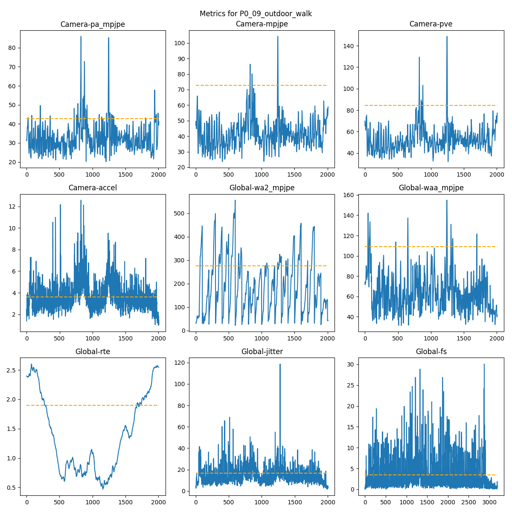

In [4]:
vid = list(pa_outlier_dict.keys())[24]
vid = 'P0_09_outdoor_walk'
print(vid)

outliers = pa_outlier_dict[vid]
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])

metrics = pkl.loads((dataset_dir / f"{vid}_results.pkl").read_bytes())
print("\n".join(f"{k}: {v.mean().item()}" for k,v in metrics.items()))
batch = torch.load(dataset_dir / f"{vid}_batch.pt")
vertice_sets = torch.load(dataset_dir / f"{vid}_pred_target.pt")
print([x['frame'] for x in outliers])
plot_img = Image.open(dataset_dir / f"{vid}_metrics.png")
plot_img.resize((512, 512))

In [63]:
start_i, end_i = 800-60, 800+60

out_video_dir = dataset_dir / f"{vid}-{start_i}-{end_i}.mp4"
target_zip = zipfile.ZipFile(root_dir / f"_{category}.zip")
writer = get_writer(out_video_dir, fps=30, crf=23)
for i in range(start_i, end_i):
    target_name = f"{category}/{vid_name}/images/{i:05d}.jpg"
    target_zip.extract(target_name, path='outputs/')
    shutil.move('outputs/' + target_name, 'tmp.png')
    writer.write_frame(np.array(Image.open("tmp.png")))
writer.close()
target_zip.close()

In [ ]:
i = 900

target_zip = zipfile.ZipFile(root_dir / f"_{category}.zip")
target_name = f"{category}/{vid_name}/images/{i:05d}.jpg"
target_zip.extract(target_name, path='outputs/')
shutil.move('outputs/' + target_name, "tmp.png")
del target_zip

target_j3d = vertice_sets['target_j3d'][i:i+1].cpu()
pred_j3d = vertice_sets['pred_j3d'][i:i+1].cpu()

pred_pelvis = pred_j3d[:, [1,2]].mean(dim=1, keepdims=True).clone()
pred_j3d -= pred_pelvis
target_pelvis = target_j3d[:, [1,2]].mean(dim=1, keepdims=True).clone()
target_j3d -= target_pelvis
perjoint_jpe = torch.sqrt(((pred_j3d - target_j3d) ** 2).sum(dim=-1))[0] * 1000.
mpjpe = perjoint_jpe.mean(-1).item()
print(mpjpe)
print(perjoint_jpe.cpu().numpy())
print(np.array(SMPLH_JOINT_NAMES)[np.where(perjoint_jpe.cpu().numpy() > mpjpe*2)[0]])

# Image.open("tmp.png").resize((360, 480))

# batch['kp2d'][i].numpy()

# image1 = Image.open("tmp.png")
# canvas = Image.new("RGB", image1.size, (127, 127, 127))
# canvas.paste(image1.crop((0, 0, 1440, 1000)), (0, 0))
# canvas.save("tmp_img.png")
# mask = Image.new("L", image1.size, 255)
# mask.paste(Image.new("L", (1440, 1000), 0), (0, 0))
# mask.save("tmp_mask.png")

47.778141021728516
[ 8.027226 10.235856 10.235869 23.026772 65.56986  13.504478 14.843289
 80.65612  41.19195  15.621423 86.24285  38.701313 40.72507  34.896484
 24.095552 44.405308 34.177223 49.540646 58.67543  87.90429  80.95491
 93.348175 93.14544  96.94983 ]
['right_hand']


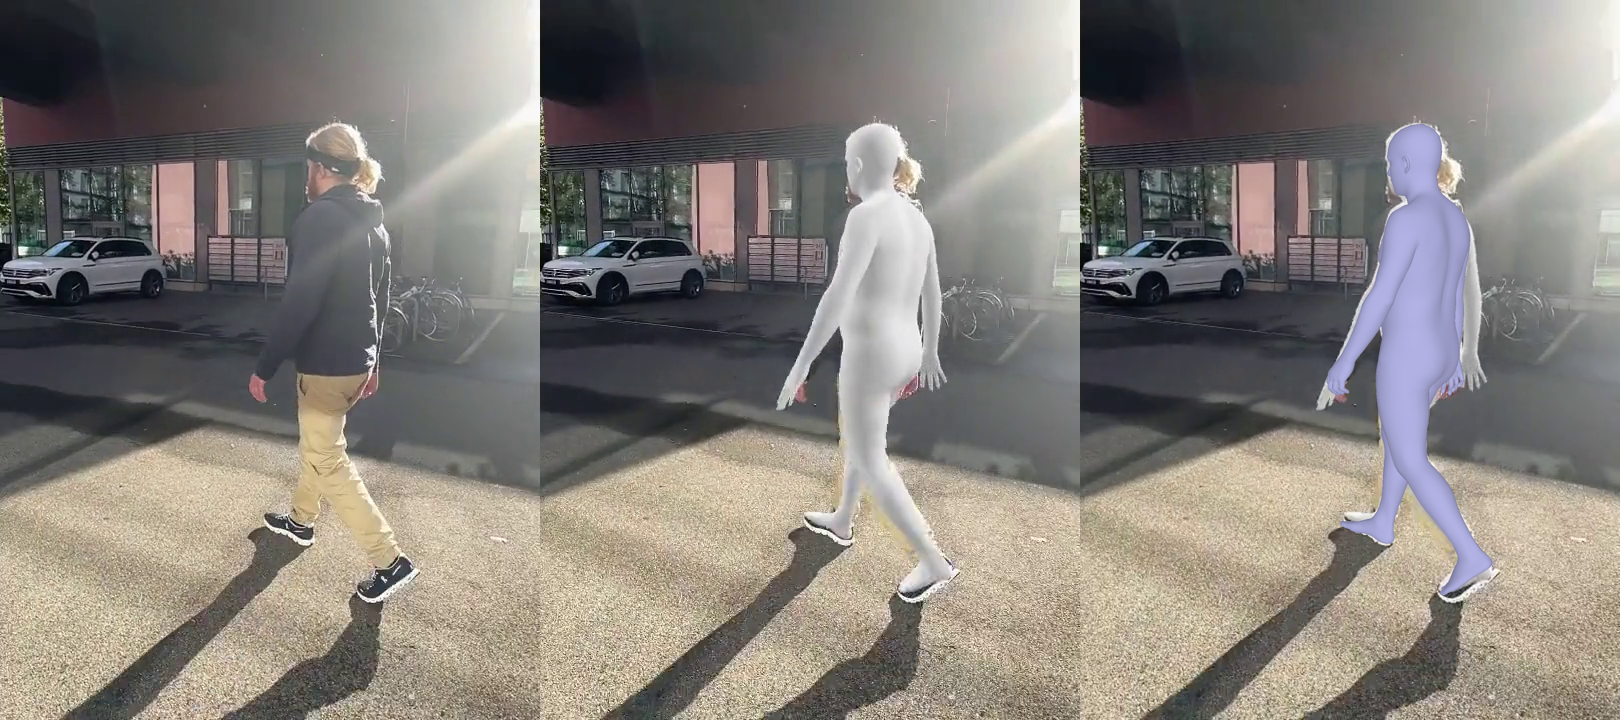

In [ ]:
video_dir = root_dir / f"{category}/{vid_name}/{vid}_video.mp4"
width_height = (1440, 1920) if vid != "P0_09_outdoor_walk" else (720, 960)
K_fullimg = estimate_K(*width_height)

width, height = int(K_fullimg[0,2].item() * 2), int(K_fullimg[1,2].item() * 2)
renderer_c = Renderer(width, height, device="cuda", faces=smpl.faces, K=K_fullimg)

combine_frame = Image.fromarray(iio.imread(video_dir, index=i))
v_w, v_h = combine_frame.size
origin_frame = combine_frame.crop((0, 0, v_w//2, v_h)).resize((width, height))
origin_frame = combine_frame.crop((v_w//2, 0, v_w, v_h)).resize((width, height))
result_frame = renderer_c.render_mesh(
    vertice_sets['pred_verts'][i].to(device), 
    background=np.array(origin_frame), 
    colors=[0.7, 0.7, 0.9])

final_frame = Image.new('RGB', (int(v_w * 1.5), v_h))
final_frame.paste(combine_frame, (0, 0))
final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
# final_frame.save(f"outputs/emdb_debug/{vid}_frame_{i}.png")
final_frame

In [ ]:
list_range = list(range(1230, 1260)) #list(range(batch['K_fullimg'].shape[1]))

writer = get_writer(f"outputs/emdb_debug/{vid}_output_{list_range[0]}_{list_range[-1]}.mp4", fps=15, crf=23)
for i in tqdm(list_range):
    K = batch['K_fullimg'][0, i]
    width, height = int(K[0,2].item() * 2), int(K[1,2].item() * 2)
    renderer_c = Renderer(width, height, device="cuda", faces=smplx.faces, K=K)

    pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(pred_ay_verts, J_regressor)
    target_gb_verts, target_gb_joints = move_to_start_point_face_z(target_w_verts, J_regressor)

    global_R, global_T, global_lights = get_global_cameras_static(
        pred_gb_joints.cpu(), beta=4.0, cam_height_degree=20, target_center_height=1.0
    )
    _, _, K = create_camera_sensor(width, height, 24)
    renderer_g = Renderer(width, height, device="cuda", faces=smpl.faces, K=K)
    # -- render mesh -- #
    scale, cx, cz = get_ground_params_from_points(pred_gb_joints[:, 0], pred_gb_verts)
    renderer_g.set_ground(scale * 1.5, cx, cz)

    combine_frame = Image.fromarray(iio.imread(video_dir, index=i))
    v_w, v_h = combine_frame.size
    origin_frame = combine_frame.crop((0, 0, v_w//2, v_h))
    origin_frame = origin_frame.resize((width, height))
    result_frame = renderer_c.render_mesh(smpl_camera.vertices[i], background=np.array(origin_frame), 
                                        colors=[0.7, 0.7, 0.9])

    cameras = renderer_g.create_camera(global_R[i], global_T[i])
    gb_verts = torch.cat([pred_gb_verts[[i]], target_gb_verts[[i]]])
    gb_colors = torch.tensor([[0.7, 0.7, 0.9], [0.8, 0.8, 0.8]], device=device)
    # gb_verts = pred_gb_verts[[i]]
    # gb_colors = torch.tensor([[0.7, 0.7, 0.9]], device=device)
    global_result_frame = renderer_g.render_with_ground(
        gb_verts,
        colors=gb_colors, 
        cameras=cameras, 
        lights=global_lights)

    final_frame = Image.new('RGB', (int(v_w * 2), v_h))
    final_frame.paste(combine_frame, (0, 0))
    final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
    final_frame.paste(Image.fromarray(global_result_frame).resize((v_w//2, v_h)), (int(v_w * 1.5), 0))
    # final_frame
    writer.write_frame(np.array(final_frame))
writer.close()

In [ ]:
for batch in test_dataset:
    vid = batch['meta']['vid']
    print(vid)

    for k, v in batch['gt_smpl_params'].items():
        batch['gt_smpl_params'][k] = batch['gt_smpl_params'][k].unsqueeze(0).to(device)
    for k in ['K_fullimg', 'T_w2c', 'T_w2ay', 'cam_angvel', 'bbx_xys', 'f_imgseq', 'kp2d']:
        batch[k] = batch[k].unsqueeze(0).to(device)
    batch['length'] = torch.tensor([batch['length']]).to(device)

    smplx_model = smplx_male if batch['gender'] == 'male' else smplx_female
    target_w_output = smplx_model(**{k: v[0] for k, v in batch["gt_smpl_params"].items()})
    target_w_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in target_w_output.vertices])
    target_c_verts = apply_T_on_points(target_w_verts, batch["T_w2c"][0])
    target_c_j3d = torch.matmul(J_regressor, target_c_verts)
    offset = target_c_j3d[..., [1, 2], :].mean(-2, keepdim=True)  # (L, 1, 3)
    target_cr_j3d = target_c_j3d - offset
    target_cr_verts = target_c_verts - offset
    # optional: ay for visual comparison
    target_ay_verts = apply_T_on_points(target_w_verts, batch["T_w2ay"][0])
    target_ay_j3d = torch.matmul(J_regressor, target_ay_verts)

    ## Calc.
    obs = normalize_kp2d(batch["kp2d"], batch["bbx_xys"])
    # obs[0, ~batch["mask"][0]] = 0

    batch_ = {
        "length": batch["length"], "obs": obs,
        "bbx_xys": batch["bbx_xys"],
        "K_fullimg": batch["K_fullimg"],
        "cam_angvel": batch["cam_angvel"],
        "f_imgseq": batch["f_imgseq"],
    }

    with torch.no_grad():
        outputs = pipeline.forward(batch_, train=False, postproc=True)
        outputs["pred_smpl_params_global"] = {k: v[0] for k, v in outputs["pred_smpl_params_global"].items()}
        outputs["pred_smpl_params_incam"] = {k: v[0] for k, v in outputs["pred_smpl_params_incam"].items()}

    smpl_camera = smplx(**outputs["pred_smpl_params_incam"])
    smpl_world = smplx(**outputs["pred_smpl_params_global"])
    pred_c_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smpl_camera.vertices])
    pred_c_j3d = einsum(J_regressor, pred_c_verts, "j v, l v i -> l j i")
    pred_ay_verts = torch.stack([torch.matmul(smplx2smpl, v_) for v_ in smpl_world.vertices])
    pred_ay_j3d = einsum(J_regressor, pred_ay_verts, "j v, l v i -> l j i")

    batch_eval_camera = {
        "pred_j3d": pred_c_j3d, "target_j3d": target_c_j3d,
        "pred_verts": pred_c_verts, "target_verts": target_c_verts,
    }
    batch_eval_global = {
        "pred_j3d_glob": pred_ay_j3d, "target_j3d_glob": target_w_j3d,
        "pred_verts_glob": pred_ay_verts, "target_verts_glob": target_w_verts,
    }
    # camcoord_metrics = compute_camcoord_metrics(batch_eval_camera, mask=batch["mask"][0])
    # global_metrics = compute_global_metrics(batch_eval_global, mask=batch["mask"][0])
    camcoord_metrics = compute_camcoord_metrics(batch_eval_camera)
    global_metrics = compute_global_metrics(batch_eval_global)
    # global_metrics = {}
    metrics = {**camcoord_metrics, **global_metrics}
    (output_dir / f"{vid}_results.pkl").write_bytes(pkl.dumps(metrics))

    ## Get Outliers
    camcoord_outliers = topk_outlier_frames(camcoord_metrics, ['pa_mpjpe', 'mpjpe', 'pve'])
    print([x['frame'] for x in camcoord_outliers])
    global_outliers = topk_outlier_frames(global_metrics, ['wa2_mpjpe', 'waa_mpjpe'])
    # global_outliers = []
    print([x['frame'] for x in global_outliers])
    outliers = camcoord_outliers + global_outliers
    (output_dir / f"{vid}_outliers.json").write_text(json.dumps(outliers, indent=4))
    
    fig, ax = plt.subplots(3, 3, figsize=(12, 12))
    for i, (key, value) in enumerate(camcoord_metrics.items()):
        ax[i//3, i%3].set_title(f"Camera-{key}")
        ax[i//3, i%3].plot(range(value.shape[0]), value)
        ax[i//3, i%3].hlines(mean_metrics[key], 0, value.shape[0]-1, colors='orange', linestyles='dashed', label='EMDB Mean')
    for j, (key, value) in enumerate(global_metrics.items()):
        j += 4
        ax[j//3, j%3].set_title(f"Global-{key}")
        ax[j//3, j%3].plot(range(value.shape[0]), value)
        ax[j//3, j%3].hlines(mean_metrics[key], 0, value.shape[0]-1, colors='orange', linestyles='dashed', label='EMDB Mean')

    fig.suptitle(f"Metrics for {vid}")
    fig.tight_layout()
    fig.savefig(output_dir / f"{vid}_metrics.png")
    
    # for k in camcoord_outliers[:3]:
    #     frame_k = k['frame']
    #     K = batch['K_fullimg'][0, frame_k]
    #     width, height = int(K[0,2].item() * 2), int(K[1,2].item() * 2)
    #     renderer_c = Renderer(width, height, device="cuda", faces=smplx.faces, K=K)

    #     pred_gb_verts, pred_gb_joints = move_to_start_point_face_z(pred_ay_verts, J_regressor)
    #     target_gb_verts, target_gb_joints = move_to_start_point_face_z(target_w_verts, J_regressor)

    #     combine_frame = Image.fromarray(iio.imread(video_dir, index=frame_k))
    #     v_w, v_h = combine_frame.size
    #     origin_frame = combine_frame.crop((0, 0, v_w//2, v_h))
    #     origin_frame = origin_frame.resize((width, height))
    #     result_frame = renderer_c.render_mesh(smpl_camera.vertices[frame_k], background=np.array(origin_frame), 
    #                                         colors=[0.7, 0.7, 0.9])

    #     final_frame = Image.new('RGB', (int(v_w * 1.5), v_h))
    #     final_frame.paste(combine_frame, (0, 0))
    #     final_frame.paste(Image.fromarray(result_frame).resize((v_w//2, v_h)), (v_w, 0))
    #     final_frame.save(output_dir / f"{vid}_frame_{frame_k}.png")

In [ ]:
vid = "P8_64_outdoor_skateboard"
i = 10
width_height = (1440, 1920)
category, vid_name = vid.split('_')[0], '_'.join(vid.split('_')[1:])
video_dir = root_dir / f"{category}/{vid_name}/{vid}_video.mp4"

label = labels[vid]
smpl_params = label["smpl_params"]

K_fullimg = estimate_K(*width_height)
T_w2c = label["T_w2c"]
R_w2c = T_w2c[:, :3, :3]
cam_angvel = compute_cam_angvel(R_w2c)

# Image.fromarray(iio.imread(video_dir, index=i)).size
# Image.open(video_dir.parent / f"images/{i:05d}.jpg").size